In [ ]:
'''
To run this shole jupyter notebook as a python script follow this:

(1) activate conda environemt
(2) go to where this notebook is located in your computer
(3) use `python` to enter python with in your shell/terminal
(4) follow the above syntax


from json import load

filename = 'qa_netmats.ipynb'
with open(filename) as fp:
    nb = load(fp)

for cell in nb['cells']:
    if cell['cell_type'] == 'code':
        source = ''.join(line for line in cell['source'] if not line.startswith('%'))
        exec(source, globals(), locals())
'''

In [77]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
# import seaborn as sns
import pandas as pd
import os

In [78]:
# load csv data
if "/Users/snaranjo" in os.getcwd():
  local_pc_flag = "/Users/snaranjo/Desktop/neurotranslate/mount_point"
else:
  local_pc_flag=""

path_to_netmats=f"{local_pc_flag}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/ABCD_NetMats/new_ABCD_version"
type="netmats" # netmats or partial_netmats
version="schaefer_d100" #schaefer_d100, schaefer_d300, glasser_d360
# subject_list_path=f"{local_pc_flag}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/wapiaw26/subject_list_only5.txt"
subject_list_path=f"{local_pc_flag}/ceph/chpc/shared/janine_bijsterbosch_group/WAPIAW_2026/qc/5min_pconn_subjects.txt"
list_of_subjects=pd.read_csv(subject_list_path, sep=" ", header=None)
list_of_subjects = list_of_subjects[0].values.tolist() #0 because no header, should be N=4551
print(f"Num of subjects: {len(list_of_subjects)}. Last 3 for reference: {list_of_subjects[-3:]}")

Num of subjects: 3234. Last 3 for reference: ['sub-T2D0E2LE', 'sub-GB1LBZ5W', 'sub-VKV5RYVF']


Randomly chosen subjects to viz are: [0 1 2 3 4]
Extracting netmat for visualization for sub:sub-WF7C1DEL
(100, 100)
Extracting netmat for visualization for sub:sub-62EXXY99
(100, 100)
Extracting netmat for visualization for sub:sub-01ELX9L6
(100, 100)
Extracting netmat for visualization for sub:sub-WHZ3DTNP
(100, 100)
Extracting netmat for visualization for sub:sub-X86DXRAK
(100, 100)


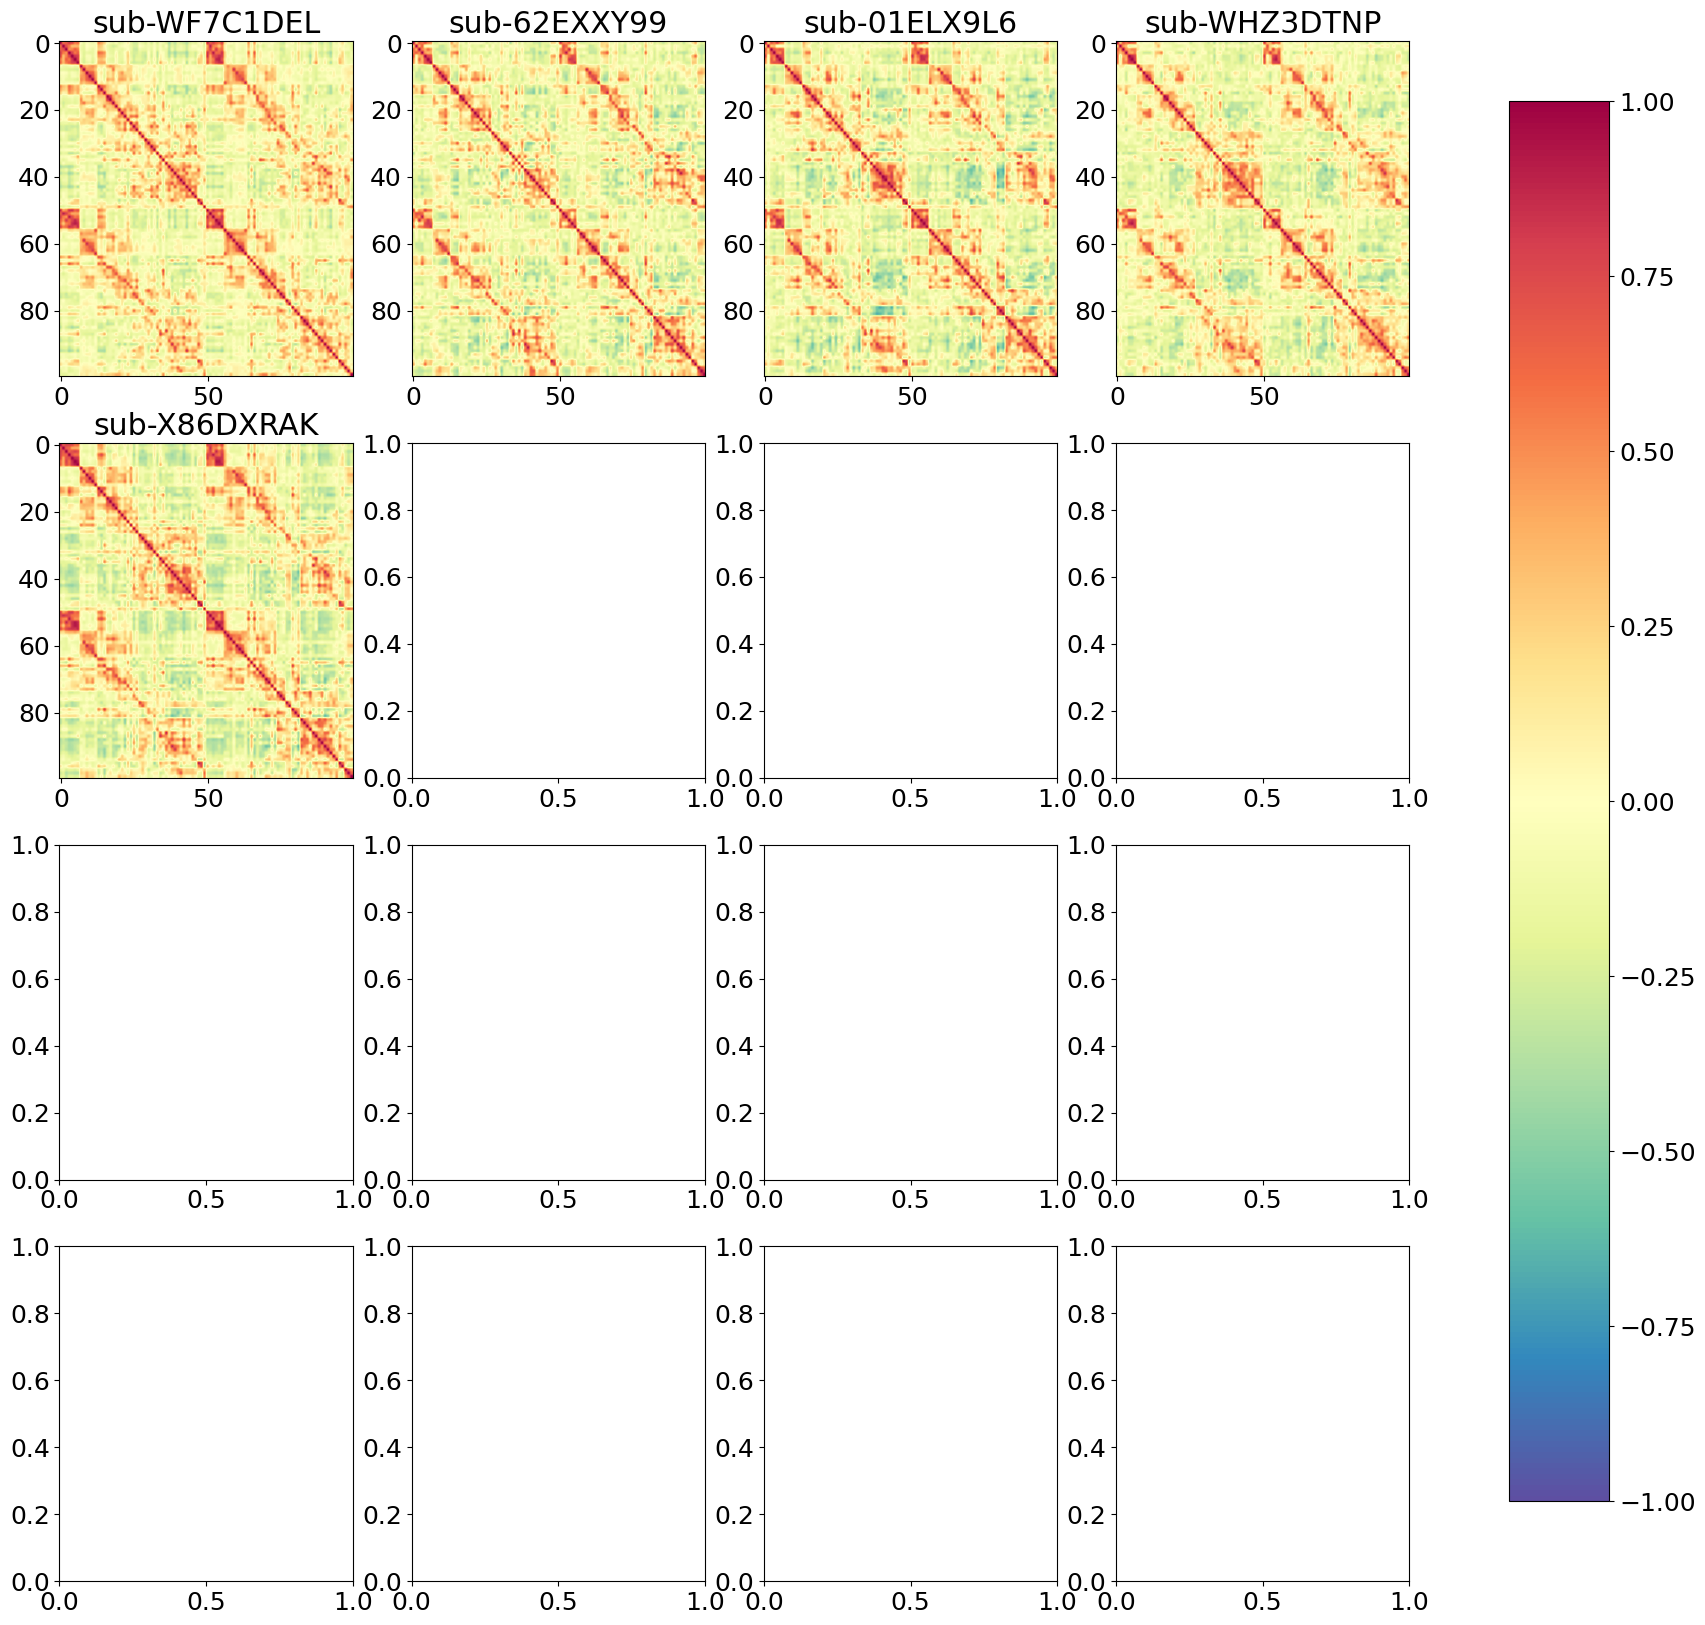

Randomly chosen subjects to viz are: [0 1 2 3 4]
Extracting netmat for visualization for sub:sub-WF7C1DEL
(100, 100)
Extracting netmat for visualization for sub:sub-62EXXY99
(100, 100)
Extracting netmat for visualization for sub:sub-01ELX9L6
(100, 100)
Extracting netmat for visualization for sub:sub-WHZ3DTNP
(100, 100)
Extracting netmat for visualization for sub:sub-X86DXRAK
(100, 100)


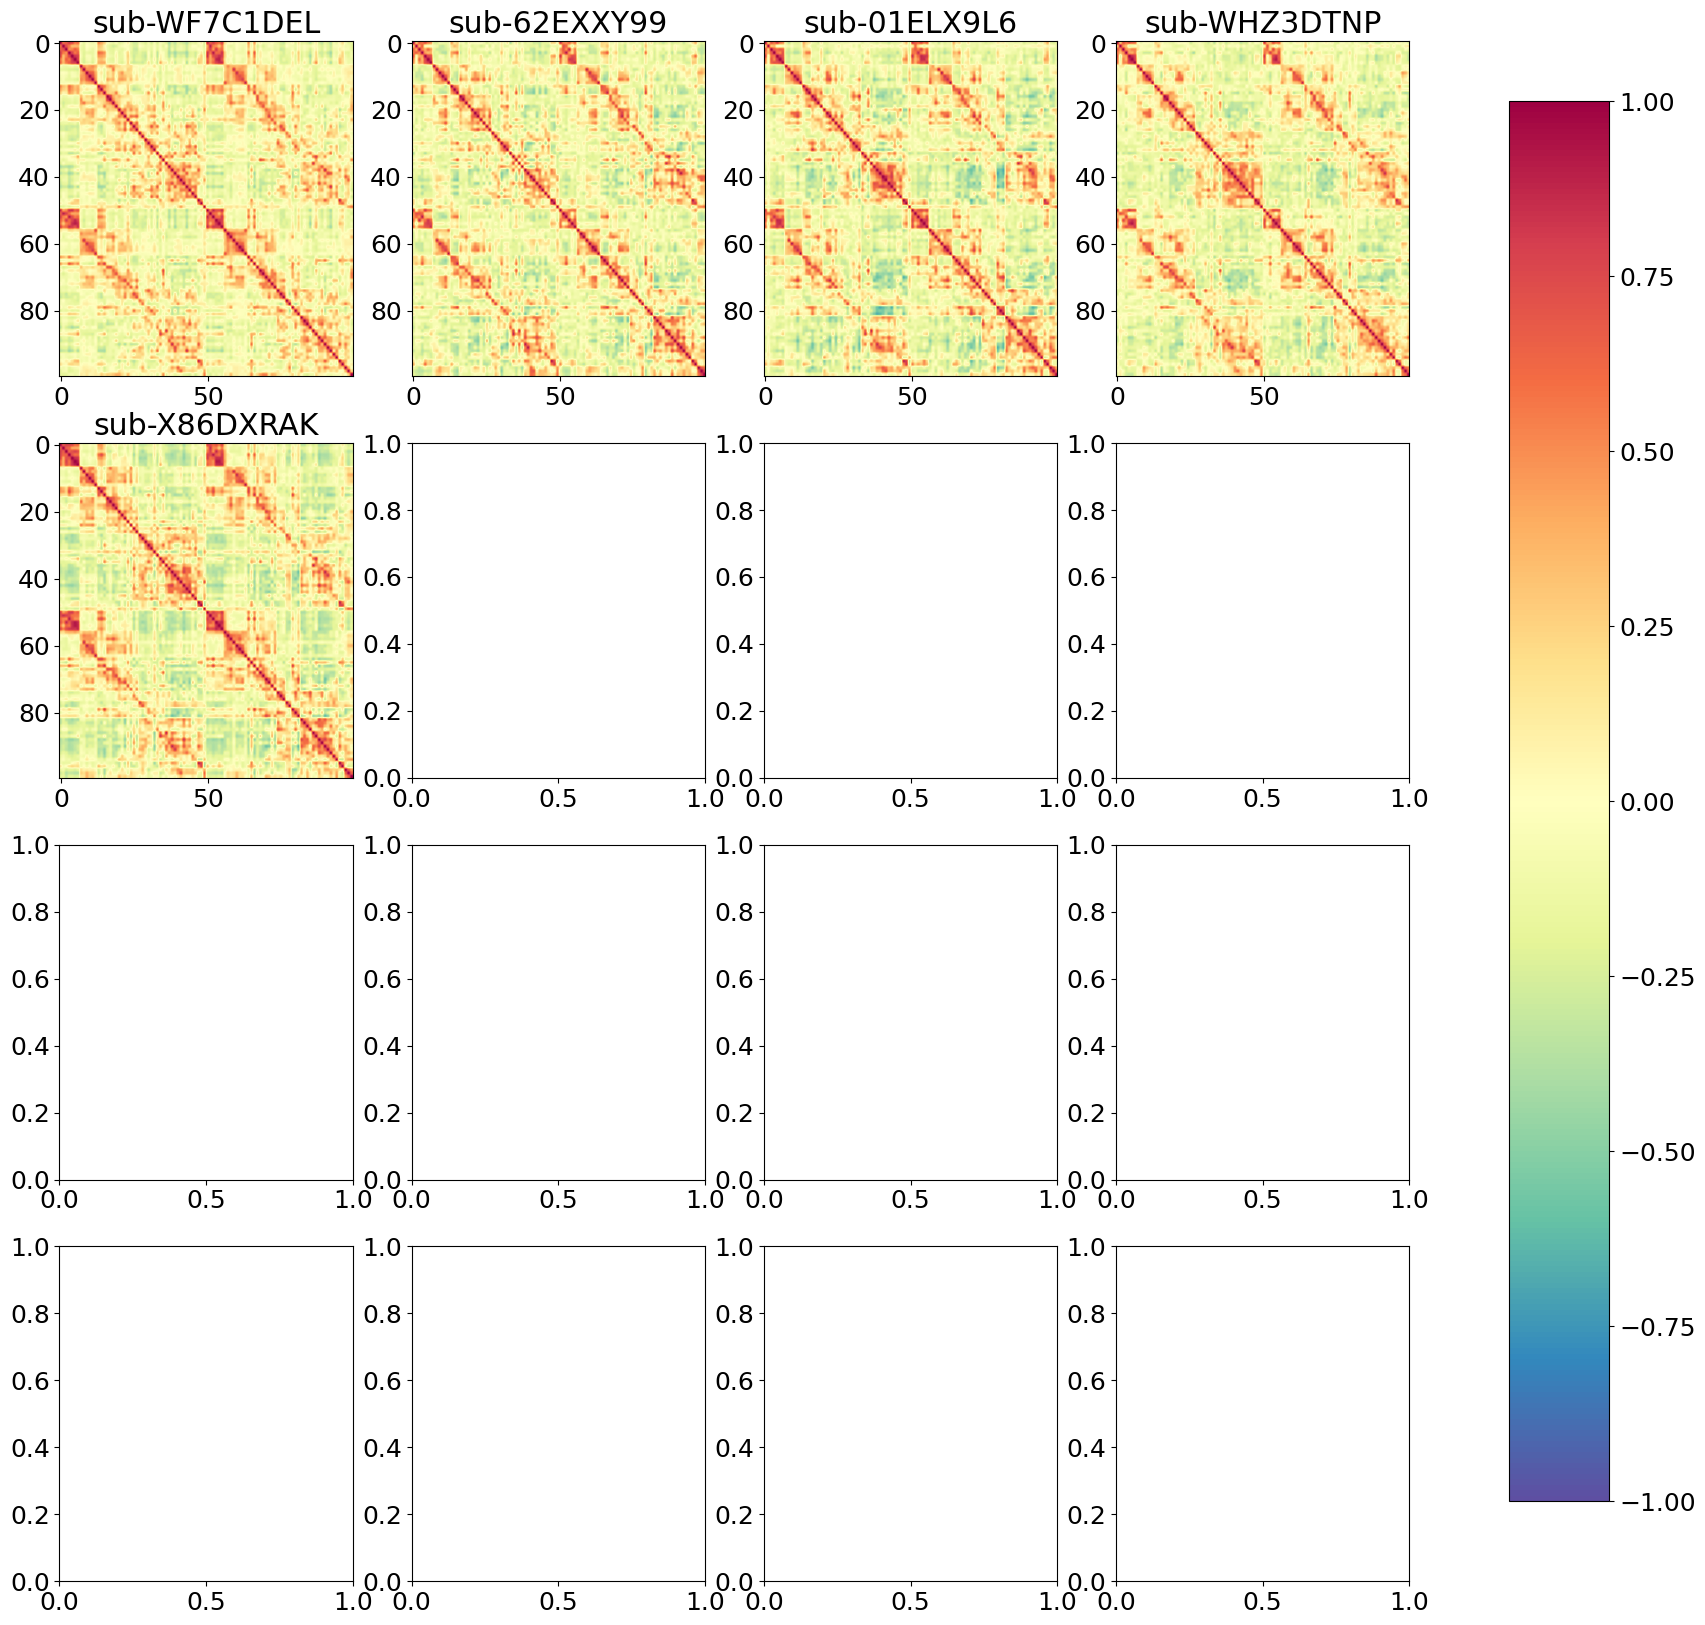

Randomly chosen subjects to viz are: [0 1 2 3 4]
Extracting netmat for visualization for sub:sub-WF7C1DEL
(100, 100)
Extracting netmat for visualization for sub:sub-62EXXY99
(100, 100)
Extracting netmat for visualization for sub:sub-01ELX9L6
(100, 100)
Extracting netmat for visualization for sub:sub-WHZ3DTNP
(100, 100)
Extracting netmat for visualization for sub:sub-X86DXRAK
(100, 100)


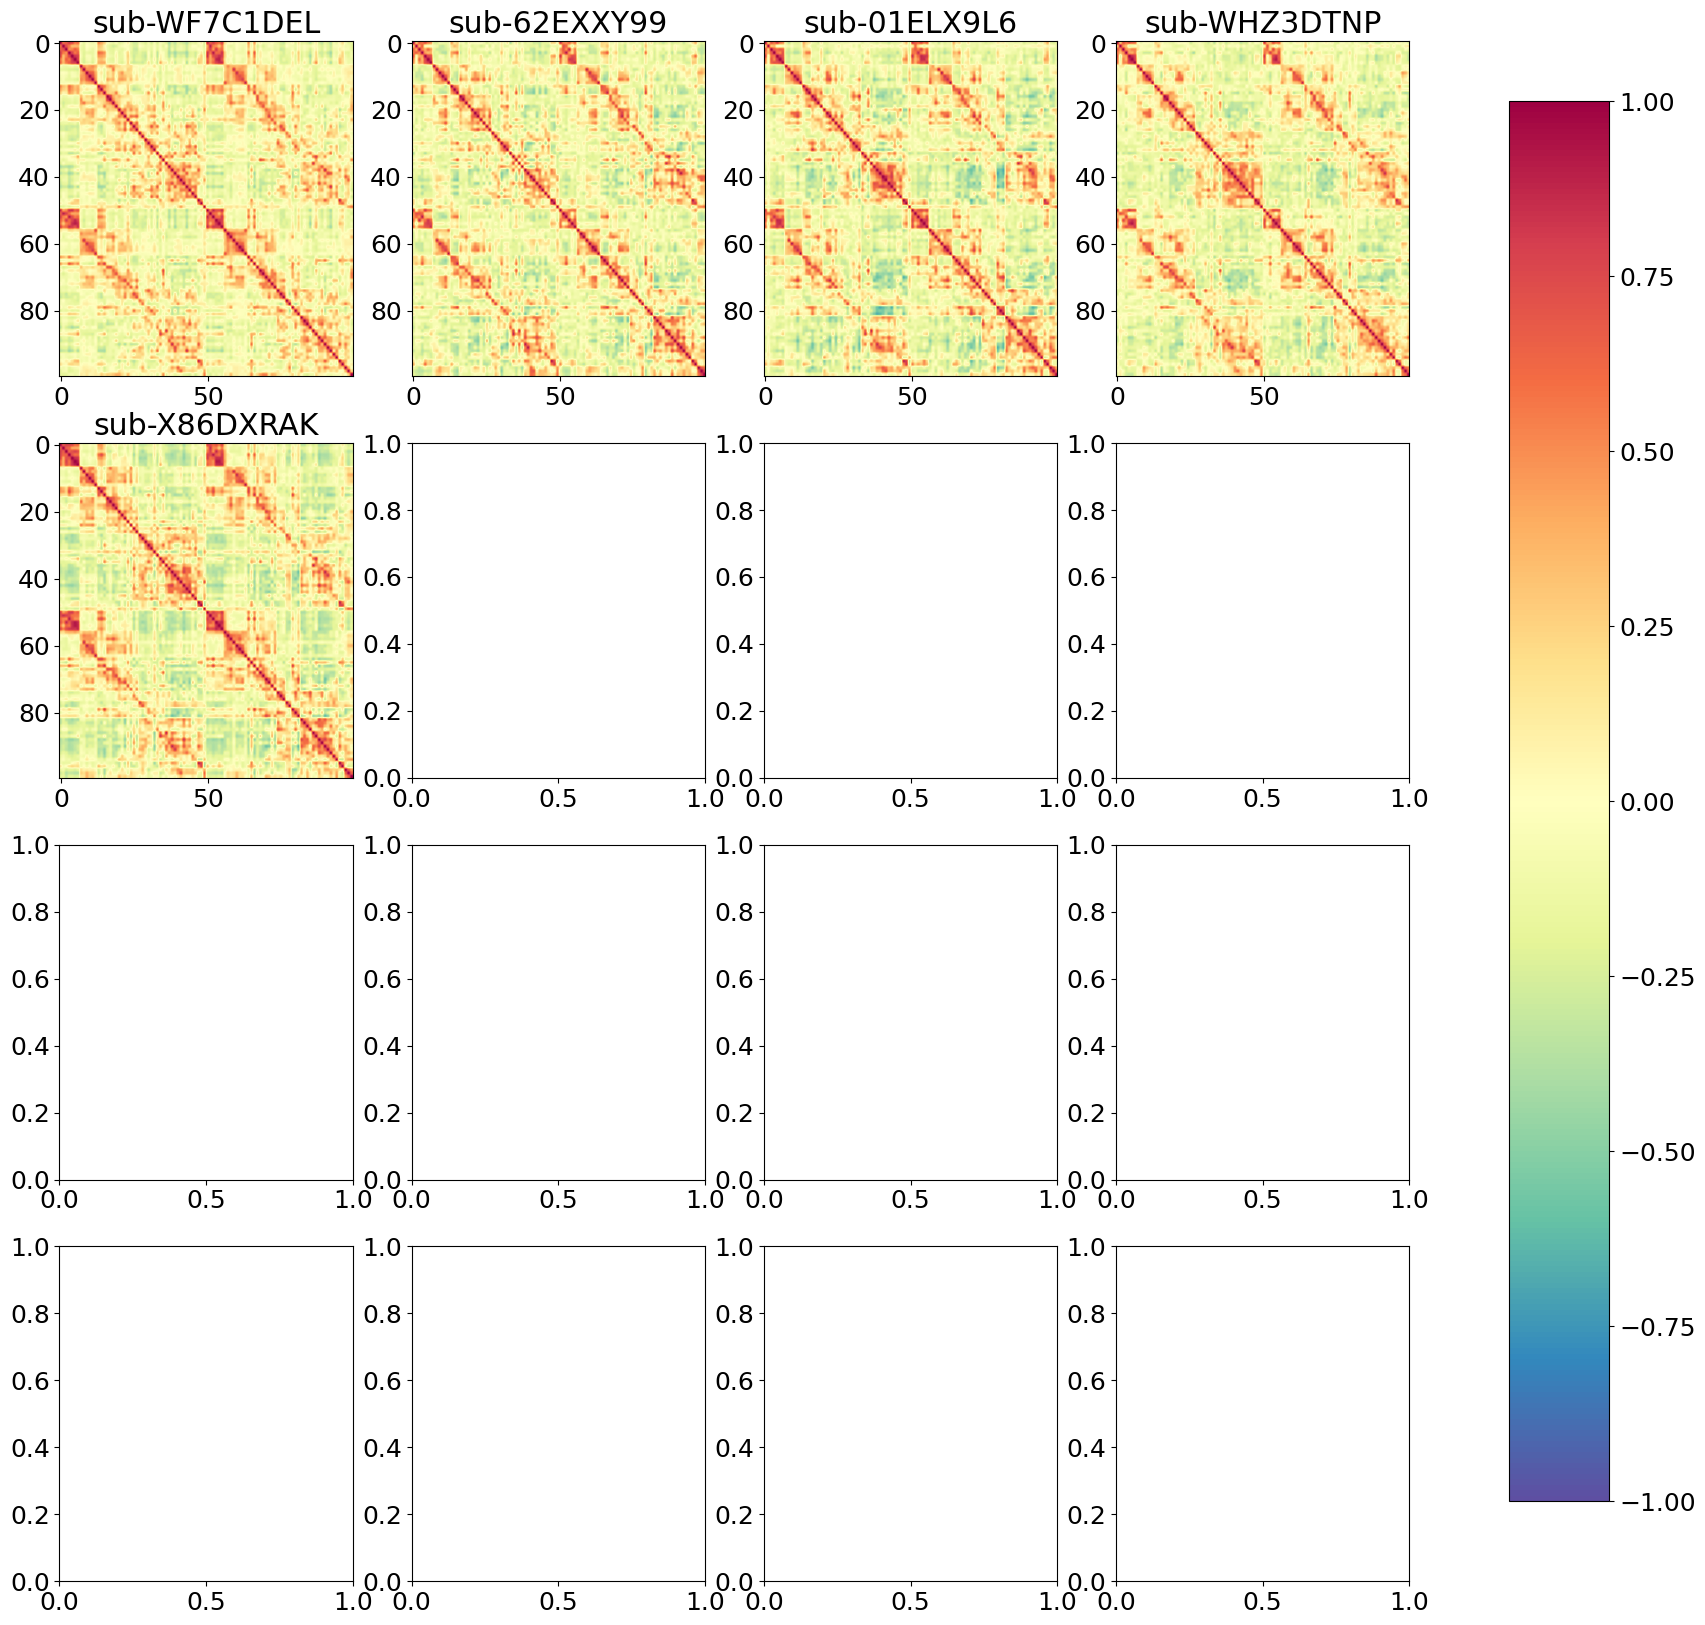

Randomly chosen subjects to viz are: [0 1 2 3 4]
Extracting netmat for visualization for sub:sub-WF7C1DEL
(100, 100)
Extracting netmat for visualization for sub:sub-62EXXY99
(100, 100)
Extracting netmat for visualization for sub:sub-01ELX9L6
(100, 100)
Extracting netmat for visualization for sub:sub-WHZ3DTNP
(100, 100)
Extracting netmat for visualization for sub:sub-X86DXRAK
(100, 100)


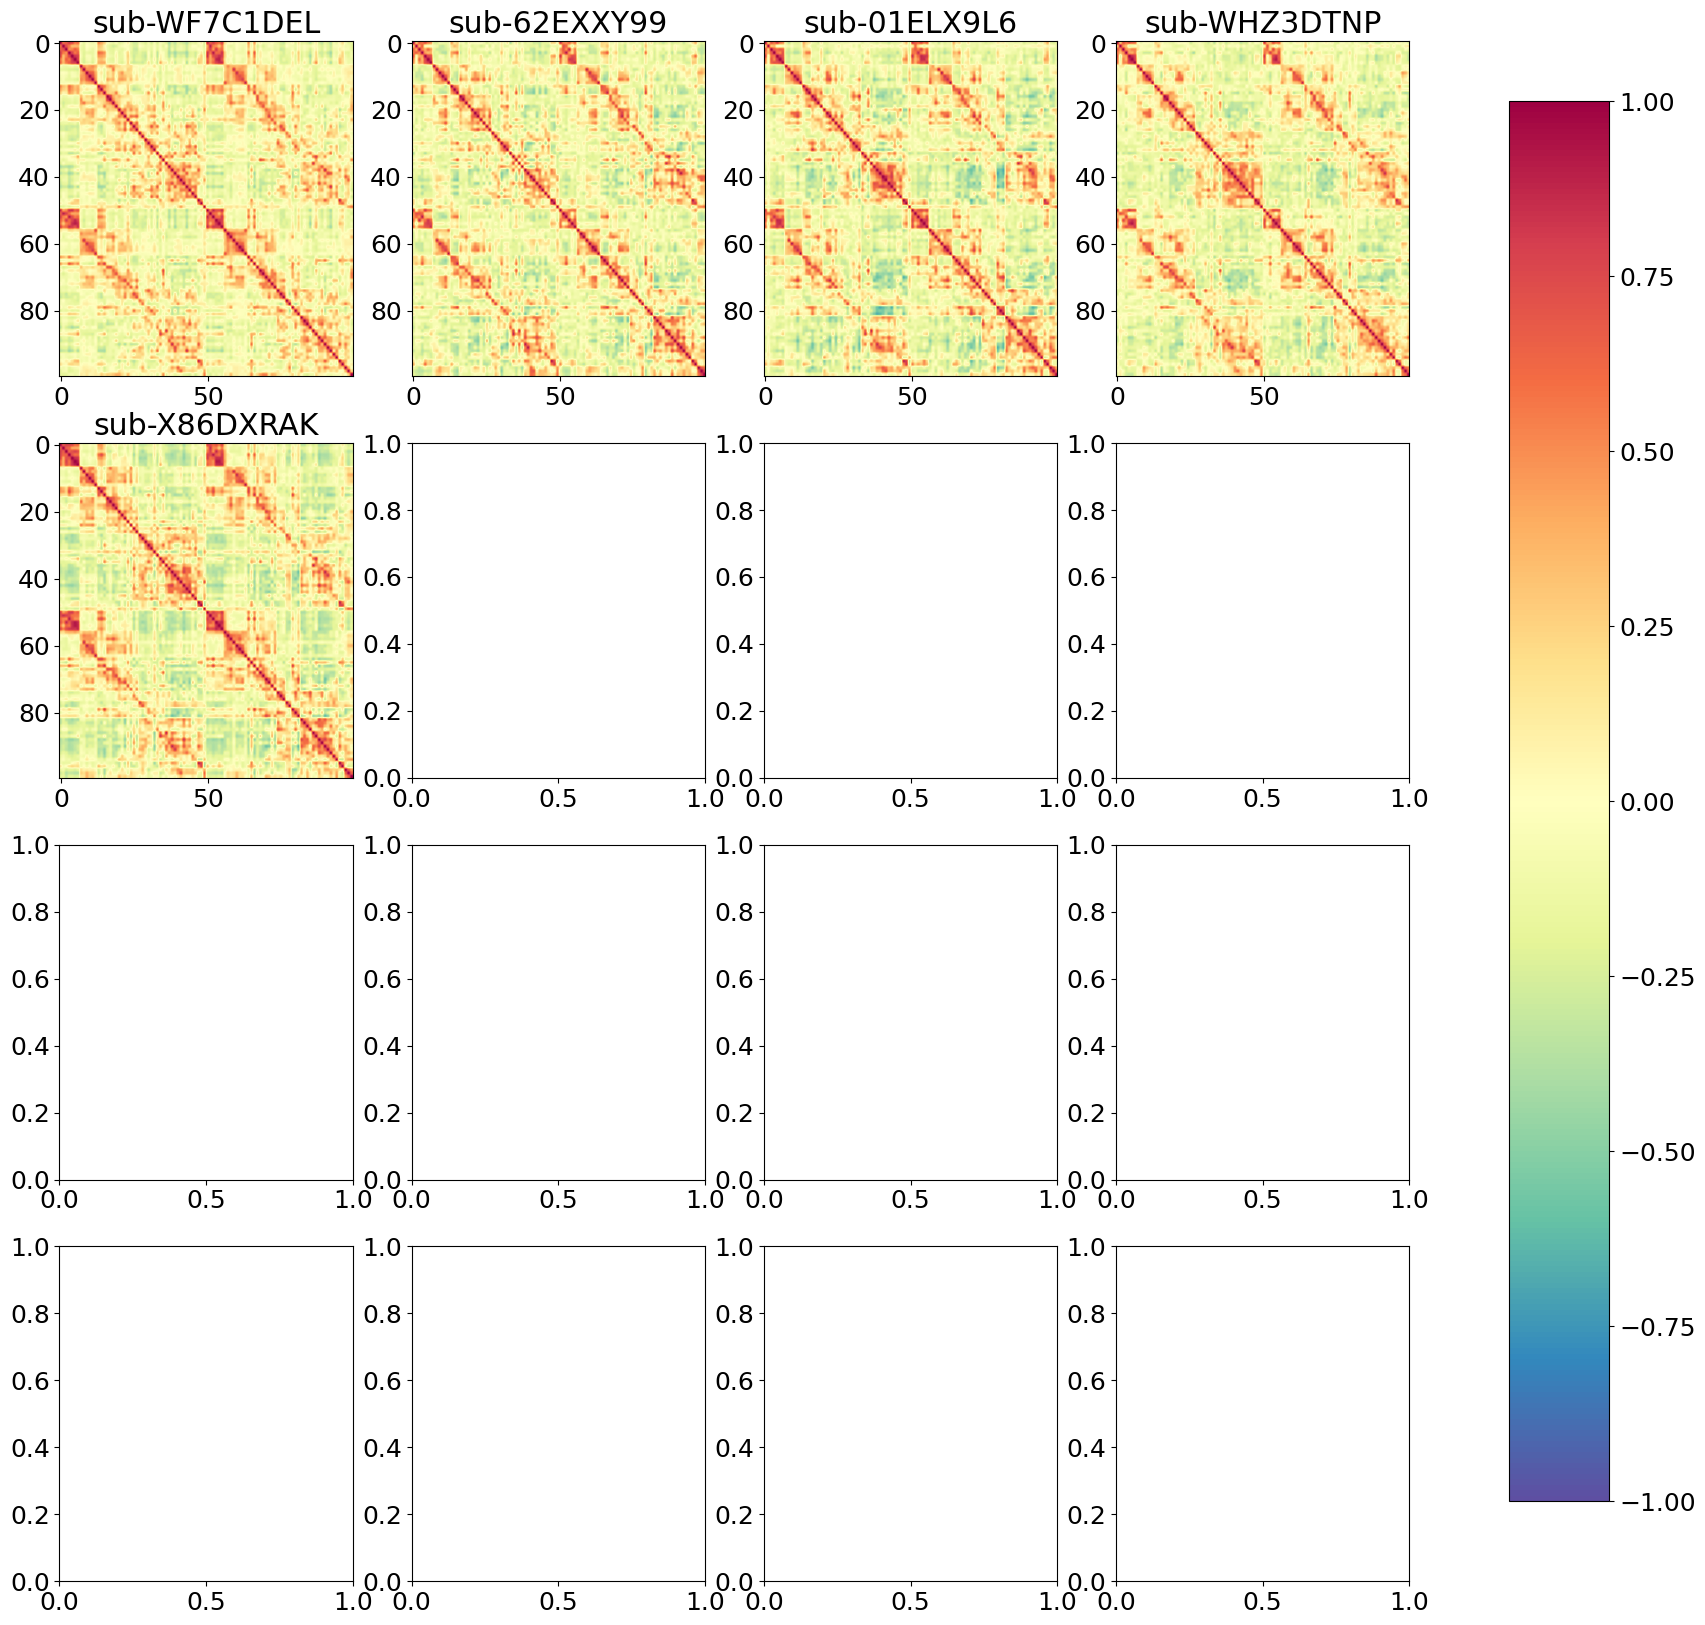

Randomly chosen subjects to viz are: [0 1 2 3 4]
Extracting netmat for visualization for sub:sub-WF7C1DEL
(100, 100)
Extracting netmat for visualization for sub:sub-62EXXY99
(100, 100)
Extracting netmat for visualization for sub:sub-01ELX9L6
(100, 100)
Extracting netmat for visualization for sub:sub-WHZ3DTNP
(100, 100)
Extracting netmat for visualization for sub:sub-X86DXRAK
(100, 100)


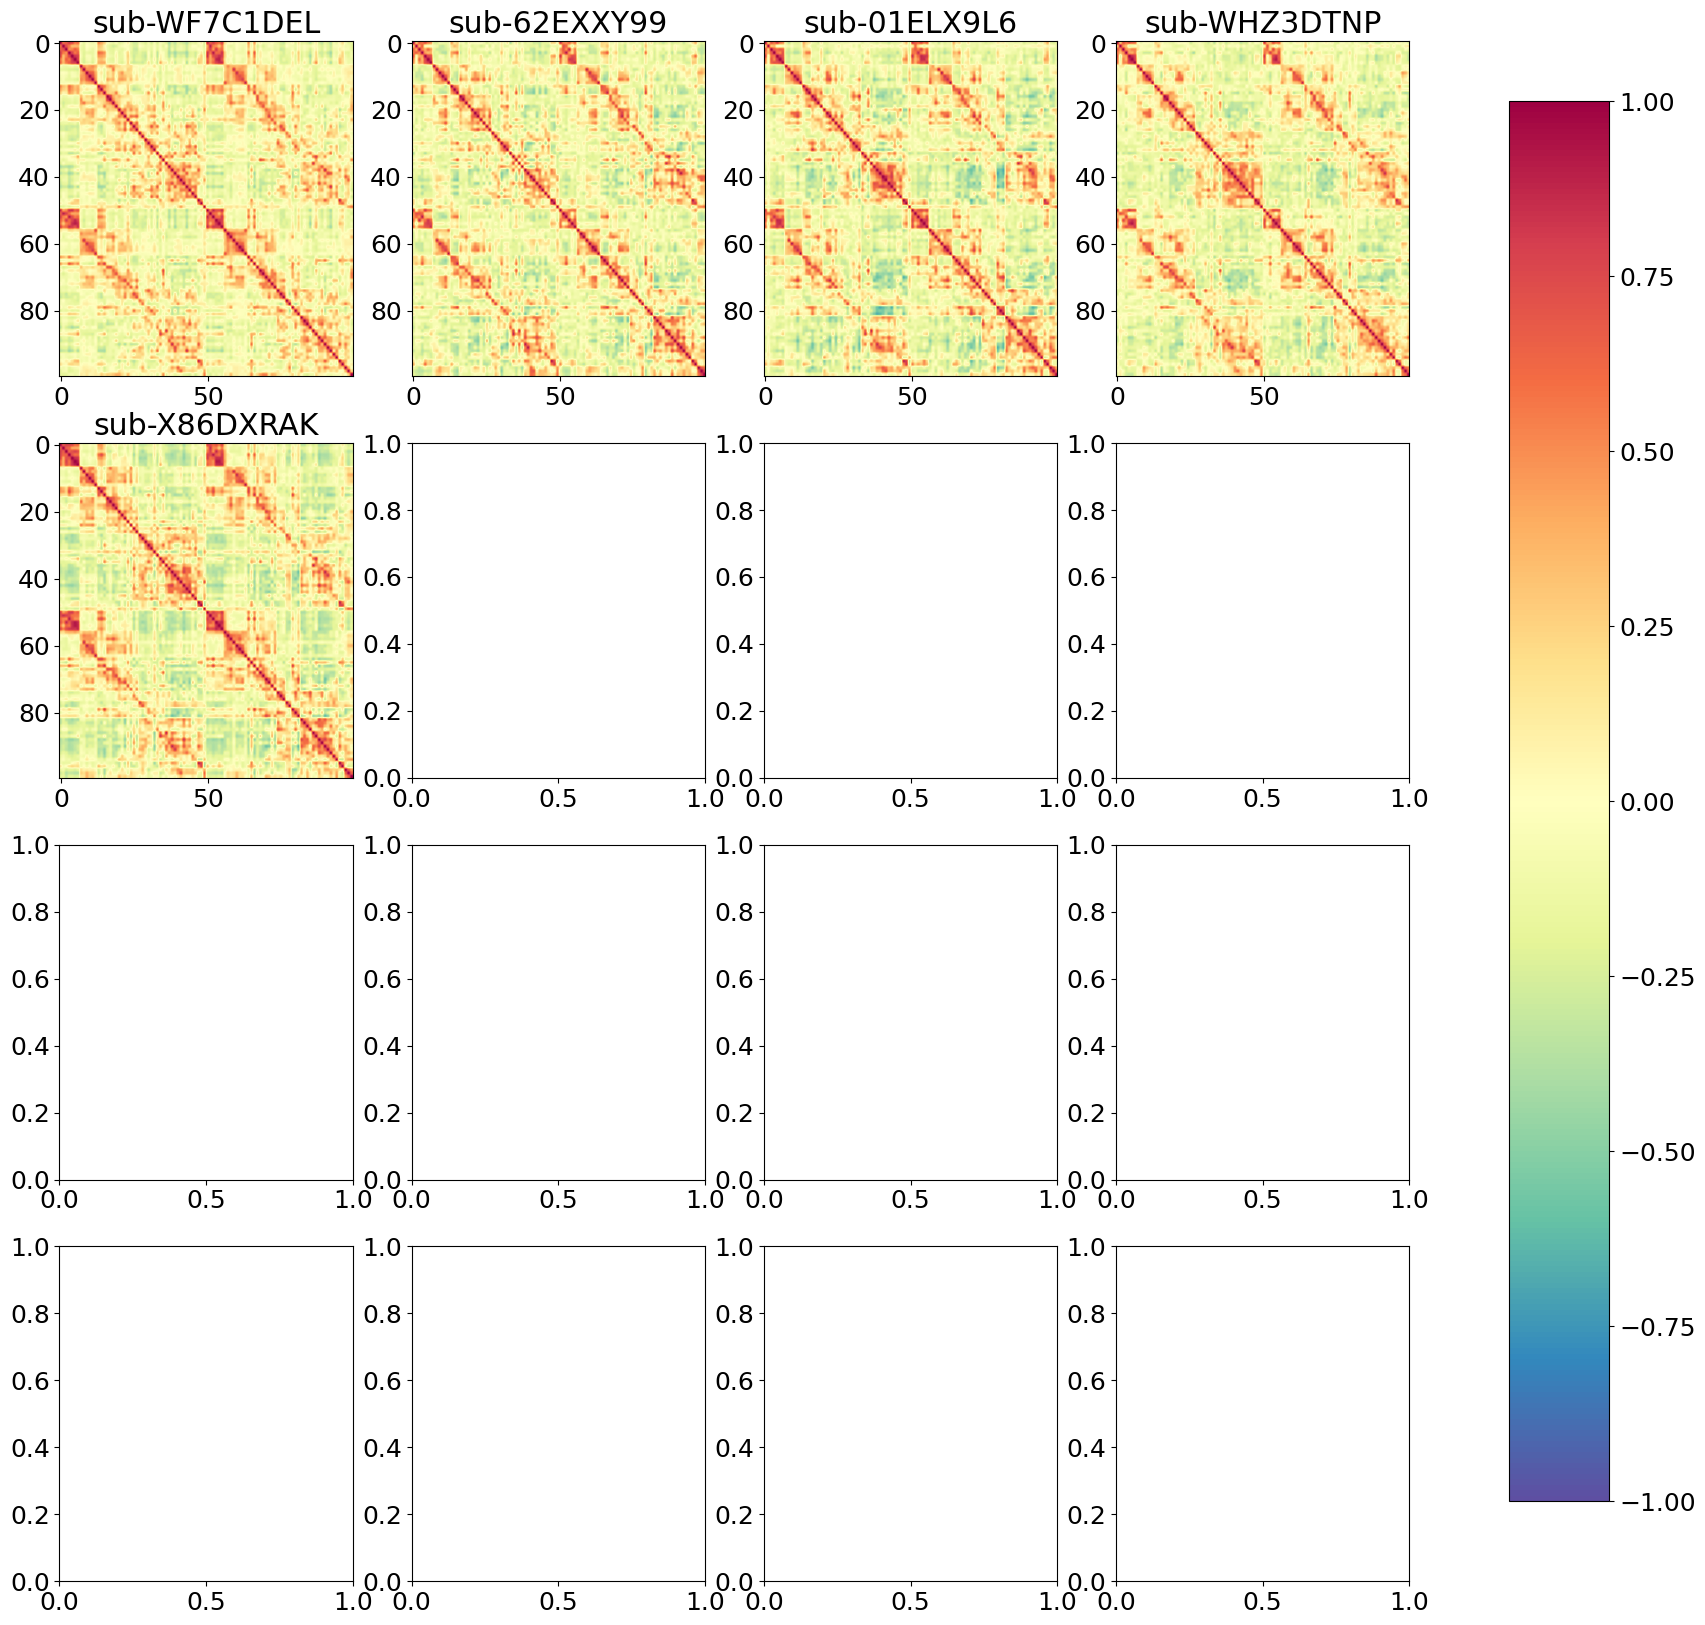

In [ ]:
directory=f"{local_pc_flag}/ceph/chpc/shared/janine_bijsterbosch_group/naranjorincon_scratch/NeuroTranslate/surf2netmat/utils/create_netmats_from_ts/images"
if not os.path.exists(directory):
        # Create the directory
        os.makedirs(directory)

for rr in range(0,5):
    # get data and check it real quick but only for random subjects
    expo_scale=4
    assert expo_scale % 2 ==0, "For visual plot, making dynamic. Needs to be an even number/"
    square_size=2**expo_scale
    random_chosen= np.unique(np.random.randint(0,len(list_of_subjects), square_size)) #power of two to correspond to square size. If you eant a 2x2 matrix then 2**2 if you want a 4x4 then 2**4 and so on.
    print(f"Randomly chosen subjects to viz are: {(random_chosen)}")

    # sub_netmat_list = []
    fig, axes = plt.subplots(square_size//expo_scale, square_size//expo_scale, figsize=(20, 20))
    axes = axes.flatten()
    for ii in range(len(random_chosen)):
        subID=list_of_subjects[random_chosen[ii]]
        print(f"Extracting netmat for visualization for sub:{subID}")
        full_path=f"{path_to_netmats}/{version}/{type}/{subID}.csv"
        get_subject_netmat=pd.read_csv(full_path, header=None).to_numpy()
        print(get_subject_netmat.shape)
        # sub_netmat_list.append(get_subject_netmat)

        im = axes[ii].imshow(get_subject_netmat, aspect="auto", vmin=-1, vmax=1, cmap="Spectral_r")
        axes[ii].set_title(f"{subID}")

    # plt.suptitle("TRAIN")
    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
    fig.colorbar(im, cax=cbar_ax)
    # plt.tight_layout()
    filename = f"/qa_check_random_{rr}.png"
    plt.savefig(directory + filename, format="png")
    # plt.show()
    plt.close()

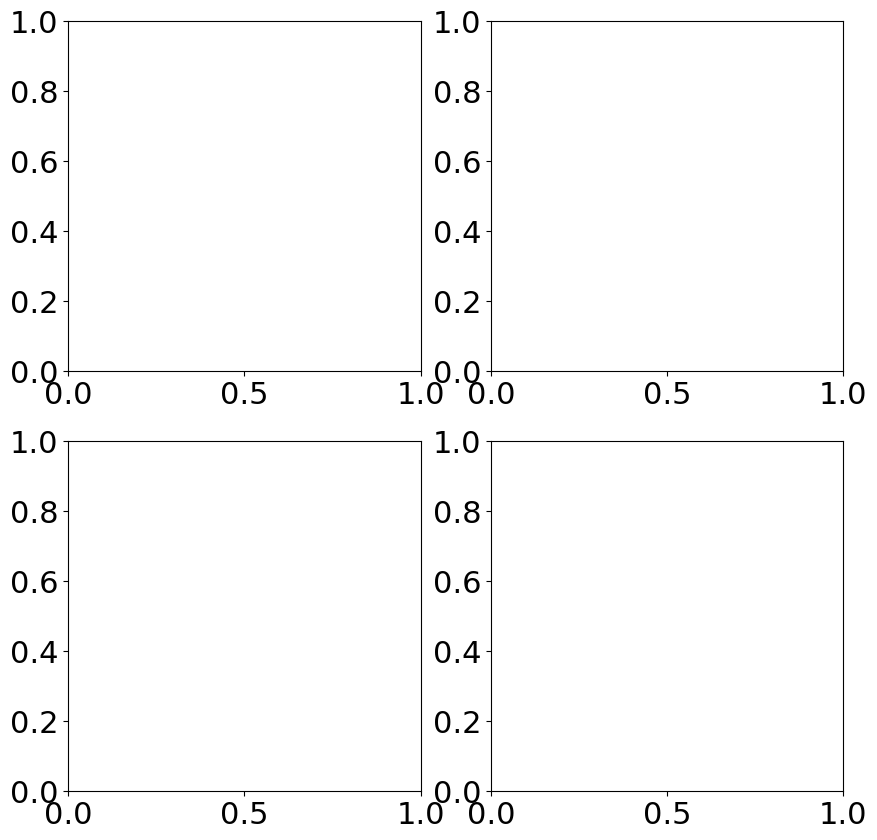

In [ ]:
fig, axes = plt.subplots(square_size//expo_scale, square_size//expo_scale, figsize=(10, 10))
axes = axes.flatten()
xx = 0
for i in range(6):
    axes[xx].imshow(sub_netmat_list[subs2view[i]].squeeze(), aspect="auto", vmin=-0.5, vmax=0.5, cmap="Spectral_r")
    axes[xx].set_title(f"True{subs2view[i]}")

plt.suptitle("TRAIN")
plt.tight_layout()
filename = f"/examples_netmats_train.{img_extension}"
# print(f"Saving to path:{directory}")
# Save the figure
# plt.savefig(directory + filename, format=img_extension)
plt.show()
plt.close()